# Profitlens - Expenses Analysis

### Business Questiones : 

1) What is the total expense and average per item?
2) Which single item costs the most?
3) How is spending distributed across categories?
4) Which category consumes the largest share of budget?
5) What % of total does each item contribute?

## 1. Imports & Style Setup

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PALETTE = ['#185FA5','#1D9E75','#D85A30','#534AB7','#BA7517','#639922']
BG      = '#FAFAF8'
BORDER  = '#D3D1C7'

sns.set_theme(style='white')
plt.rcParams.update({
    'axes.facecolor'    : BG,
    'figure.facecolor'  : BG,
    'axes.edgecolor'    : BORDER,
    'axes.linewidth'    : 0.6,
    'grid.color'        : BORDER,
    'grid.linewidth'    : 0.5,
    'axes.grid'         : True,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : '500',
    'axes.labelsize'    : 11,
})
print('Setup complete.')

Setup complete.


## 2. Loaded & Inspect the Dataset

In [4]:
df = pd.read_csv("E:/Python/profitlens/data/processed/expenses_cleaned.csv")
df.columns = df.columns.str.strip()

print(f"Shape : {df.shape[0]} rows x {df.shape[1]} columns")
print(f'Columns: {df.columns.tolist()}')
df

Shape : 13 rows x 2 columns
Columns: ['particular', 'amount']


,particular,amount
0,Large Bag,380
1,"Stationary(Soft Pin, Paper pin for Dupatta, Fe...",170
2,OLA,839
3,Auto Rent,520
4,TT Fine,500
5,Bhushan Hotel,2506
6,Food,1290
7,Expomart Labour Charge,200
8,Choclate,400
9,Bhushan Cash,800


In [5]:
print("Data types:")
print(df.dtypes)
print()
print("Null Values:")
print(df.isnull().sum())
print()
print("Numeric Summary")
df[["amount"]].describe().round(2)

Data types:
particular    object
amount         int64
dtype: object

Null Values:
particular    0
amount        0
dtype: int64

Numeric Summary


,amount
count,13.00
mean,622.69
std,661.46
min,70.00
25%,200.00
50%,400.00
75%,800.00
max,2506.00


## 3. Feature Engineering - Add Category & Percentage

In [6]:
#Assign a category to each expense  item based on keywords
 
def categories(name):
    name = name.lower()
    if any(x in name for x in ["ola", "auto", "tt fine", "cooli"]):
        return "Transport"
    if any(x in name for x in ["hotel", "rest room"]):
        return "Accommodation"
    if any(x in name for x in ["food", "chocolate", "water"]):
        return "Food & Drinks"
    if any(x in name for x in ["stationary", "bag"]):
        return "Supplies"
    if any(x in name for x in ["labour", "expomart"]):
        return "Labour"
    return "Miscellaneous"

df["category"] = df["particular"].apply(categories)

# calculate % contribution of each item
df["pct"] = (df["amount"] / df["amount"].sum() * 100).round(1)

print("Updated DataFrame:")
df

Updated DataFrame:


,particular,amount,category,pct
0,Large Bag,380,Supplies,4.7
1,"Stationary(Soft Pin, Paper pin for Dupatta, Fe...",170,Supplies,2.1
2,OLA,839,Transport,10.4
3,Auto Rent,520,Transport,6.4
4,TT Fine,500,Transport,6.2
5,Bhushan Hotel,2506,Accommodation,31.0
6,Food,1290,Food & Drinks,15.9
7,Expomart Labour Charge,200,Labour,2.5
8,Choclate,400,Miscellaneous,4.9
9,Bhushan Cash,800,Miscellaneous,9.9


## 4. Key Metrics Summary

In [11]:
total = df["amount"].sum()
avg = df["amount"].mean()
highest = df.loc[df["amount"].idxmax()]
lowest = df.loc[df["amount"].idxmin()]
top_cat = df.groupby("category")["amount"].sum().idxmax()

print("=" * 40)
print(f"Total Expenses     :   ₹{total:,}")
print(f"Number of Items    :   {len(df)}")
print(f"Average per Item   :   ₹{avg:.0f}")
print(f"Highest Expense    :   {highest["particular"][:30]}")
print(f"                       ₹{highest["amount"]:,}({highest["pct"]}%)")
print(f"Lowest Expense     :   {lowest["particular"][:30]}")
print(f"                       ₹{lowest["amount"]:,}({lowest["pct"]}%)")
print(f"Top Category       :   {top_cat}")
print("=" * 40)

Total Expenses     :   ₹8,095
Number of Items    :   13
Average per Item   :   ₹623
Highest Expense    :   Bhushan Hotel
                       ₹2,506(31.0%)
Lowest Expense     :   Water Bottel
                       ₹70(0.9%)
Top Category       :   Accommodation


## 5. Analysis & Visualisations

### 5.1 Expense Breakdown by Item

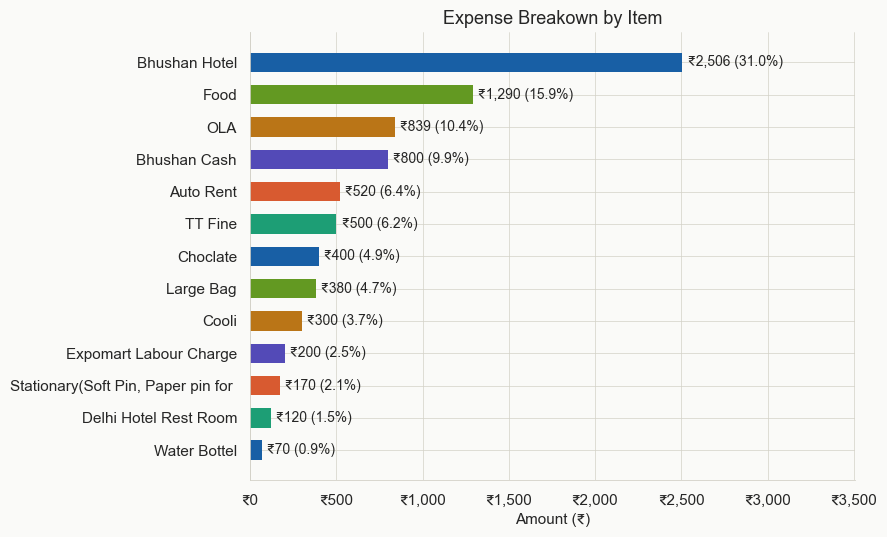

In [12]:
df_sorted = df.sort_values("amount", ascending=True)
colors = [PALETTE[i % len(PALETTE)] for i in range(len(df_sorted))]

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.barh(
    df_sorted["particular"].str[:35],
    df_sorted["amount"],
    color=colors, height=0.6, edgecolor="none"
)

# Add value labels on each bar
for bar, val, pct in zip(bars, df_sorted["amount"], df_sorted["pct"]):
    ax.text(
        val + 30,
        bar.get_y() + bar.get_height() / 2,
        f"₹{val:,} ({pct}%)",
        va="center", fontsize=10
    )

ax.set_title("Expense Breakown by Item")
ax.set_xlabel("Amount (₹)")
ax.set_xlim(0, df["amount"].max() * 1.4)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{int(x):,}"))

plt.tight_layout()
plt.savefig("E:/Python/profitlens/src/output/expenses/01_expenses_by_item.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.2 Category Share - Donut Chart + Bar Chart

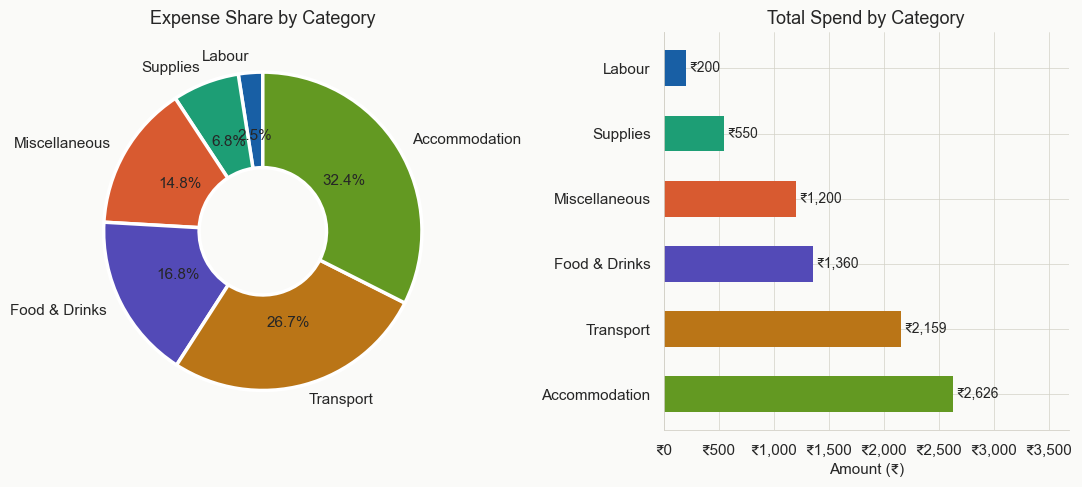

Category-wise totals:
 Labour               ₹200 (2.5%)
 Supplies             ₹550 (6.8%)
 Miscellaneous        ₹1,200 (14.8%)
 Food & Drinks        ₹1,360 (16.8%)
 Transport            ₹2,159 (26.7%)
 Accommodation        ₹2,626 (32.4%)


In [13]:
cat_sum = df.groupby("category")["amount"].sum().sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(11,5))
fig.patch.set_facecolor(BG)

# Donut Chart
axes[0].pie(
    cat_sum.values,
    labels = cat_sum.index,
    autopct = "%1.1f%%",
    colors = PALETTE[:len(cat_sum)],
    startangle = 90,
    wedgeprops = {"edgecolor" : "white", "linewidth" : 2.5, "width" : 0.6},
    textprops = {"fontsize" : 11}
)
axes[0].set_title("Expense Share by Category")

# Bar Chart
axes[1].barh(
    cat_sum.index[::-1], cat_sum.values[::-1],
    color = PALETTE[:len(cat_sum)][::-1],
    height=0.55, edgecolor="none"
)

for i, (cat, val) in enumerate(zip(cat_sum.index[::-1], cat_sum.values[::-1])):
    axes[1].text(val + 30, i, f"₹{val:,}", va="center", fontsize=10)

axes[1].set_title("Total Spend by Category")
axes[1].set_xlabel("Amount (₹)")
axes[1].set_xlim(0, cat_sum.max() * 1.4)
axes[1].set_facecolor(BG)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"₹{int(x):,}"))

plt.tight_layout()
plt.savefig("E:/Python/profitlens/src/output/expenses/02_expenses_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

print("Category-wise totals:")
for cat, val in cat_sum.items():
    print(f" {cat:<20} ₹{val:,} ({val/total*100:.1f}%)")

### 5.3 Cumulative Spend - Pareto Chart

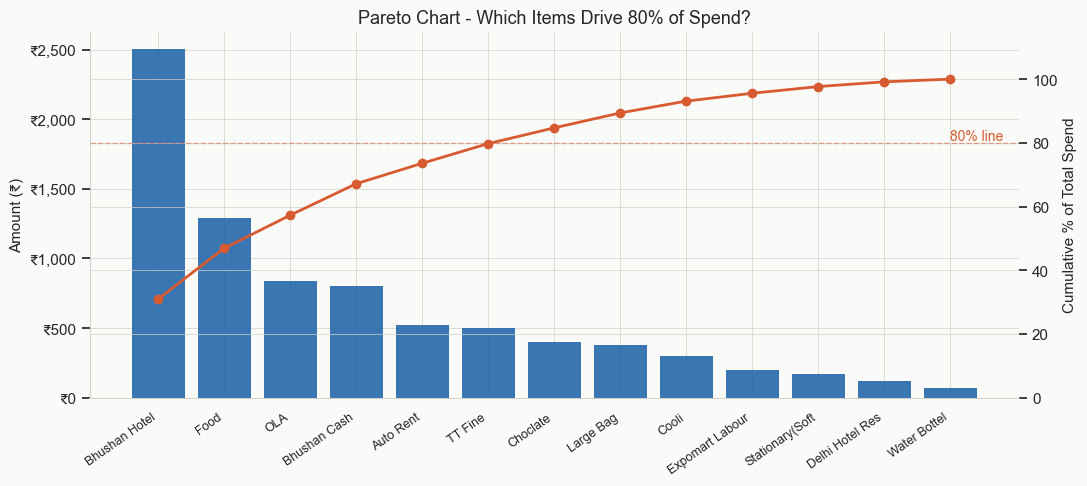

Items making up ~80% of spend: 7 out of 13
   particular  amount  cumulative_pct
Bhushan Hotel    2506       30.957381
         Food    1290       46.893144
          OLA     839       57.257566
 Bhushan Cash     800       67.140210
    Auto Rent     520       73.563928
      TT Fine     500       79.740581
     Choclate     400       84.681902


In [18]:
# Pareto = which items  account  for 80% of total spend?

df_par = df.sort_values("amount", ascending=False).reset_index(drop=True)
df_par["cumulative_pct"] = df_par["amount"].cumsum() / df_par["amount"].sum() * 100

fix, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.bar(
    range(len(df_par)),
    df_par["amount"],
    color = PALETTE[0], edgecolor = "none", alpha = 0.85
)

ax2.plot(
    range(len(df_par)),
    df_par["cumulative_pct"],
    color=PALETTE[2], linewidth=2, marker='o', markersize=6
)

ax2.axhline(80, color=PALETTE[2], linewidth=1, linestyle="--", alpha=0.5)
ax2.text(len(df_par)-1, 81, "80% line", color=PALETTE[2], fontsize=10)

ax1.set_xticks(range(len(df_par)))
ax1.set_xticklabels(
    [p[:15] for p in df_par["particular"]],
    rotation=35, ha="right", fontsize=9
)

ax1.set_ylabel("Amount (₹)")
ax2.set_ylabel("Cumulative % of Total Spend")
ax1.set_title("Pareto Chart - Which Items Drive 80% of Spend?")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"₹{int(x):,}"))
ax2.set_ylim(0, 115)

plt.tight_layout()
plt.savefig("E:/Python/profitlens/src/output/expenses/03_expenses_paretopng", dpi=150, bbox_inches="tight")
plt.show()

# Find items that make up 80% of spend
top80 = df_par[df_par['cumulative_pct'] <= 80]
print(f'Items making up ~80% of spend: {len(top80)+1} out of {len(df_par)}')
print(df_par[['particular','amount','cumulative_pct']].head(len(top80)+1).to_string(index=False))

### 5.4 Category vs Item Detail - Grouped View

In [19]:
cat_detail = df.groupby("category")[["particular", "amount"]].apply(
    lambda x:x.sort_values("amount", ascending=False)
).reset_index(drop=True)

print("Item detail by category:")
print()

for cat in cat_sum.index:
    items = df[df["category"] == cat].sort_values("amount", ascending=False)
    cat_total = items["amount"].sum()
    print(f" [{cat}]    Total : ₹{cat_total:,}")
    for _, row in items.iterrows():
        print(f" • {row["particular"][:40]:<42}  ₹{row["amount"]:>6,}  ({row["pct"]}%)")
    print()

Item detail by category:

 [Labour]    Total : ₹200
 • Expomart Labour Charge                      ₹   200  (2.5%)

 [Supplies]    Total : ₹550
 • Large Bag                                   ₹   380  (4.7%)
 • Stationary(Soft Pin, Paper pin for Dupat    ₹   170  (2.1%)

 [Miscellaneous]    Total : ₹1,200
 • Bhushan Cash                                ₹   800  (9.9%)
 • Choclate                                    ₹   400  (4.9%)

 [Food & Drinks]    Total : ₹1,360
 • Food                                        ₹ 1,290  (15.9%)
 • Water Bottel                                ₹    70  (0.9%)

 [Transport]    Total : ₹2,159
 • OLA                                         ₹   839  (10.4%)
 • Auto Rent                                   ₹   520  (6.4%)
 • TT Fine                                     ₹   500  (6.2%)
 • Cooli                                       ₹   300  (3.7%)

 [Accommodation]    Total : ₹2,626
 • Bhushan Hotel                               ₹ 2,506  (31.0%)
 • Delhi Hotel Rest 

## 6. Key Insights Summary

In [20]:
print('=' * 55)
print('  EXPENSE ANALYSIS — KEY INSIGHTS')
print('=' * 55)
print(f'  1. Total spend          : ₹{total:,} across {len(df)} items')
print(f'  2. Biggest single item  : {highest["particular"][:30]}')
print(f'                            ₹{highest["amount"]:,} ({highest["pct"]}% of total)')
print(f'  3. Top category         : {top_cat}')
print(f'                            ₹{cat_sum[top_cat]:,} ({cat_sum[top_cat]/total*100:.1f}% of total)')
print(f'  4. Accommodation + Transport = ₹{cat_sum["Accommodation"]+cat_sum["Transport"]:,}')
print(f'                            ({(cat_sum["Accommodation"]+cat_sum["Transport"])/total*100:.1f}% of budget)')
print(f'  5. Top 4 items drive ~80% of total spend (Pareto)')
print('=' * 55)

  EXPENSE ANALYSIS — KEY INSIGHTS
  1. Total spend          : ₹8,095 across 13 items
  2. Biggest single item  : Bhushan Hotel
                            ₹2,506 (31.0% of total)
  3. Top category         : Accommodation
                            ₹2,626 (32.4% of total)
  4. Accommodation + Transport = ₹4,785
                            (59.1% of budget)
  5. Top 4 items drive ~80% of total spend (Pareto)
